# Missing Data

By the end of this worksheet, you should be able to:

- Identify different types and mechanisms of missing data in real and simulated datasets.
- Diagnose and visualize missingness using the `naniar` package.
- Implement simple deterministic imputation methods from scratch and using existing R functions.
- Apply multiple imputation using the `mice` package and interpret its output.
- Evaluate how different missing-data strategies affect downstream analyses such as regression modelling.

## Introduction to Missing Data

Missing data occurs when no value is stored for a variable in an observation. In R, missing values are typically represented as `NA`, but in real-world data missing values can be reported with different values, including "na", "N/A", 9999, empty cells, etc.

Missing data can occur due to several reasons including but not limited to data corruption, non-responses from surveys, study design and unrecorded data. Missing data may result from different mechanisms, as discussed during lecture:
1. MCAR (Missing Completely At Random)
2. MAR (Missing At Random)
3. MNAR (Missing Not At Random)

## Data with Missing Values

To better understand how to visualize and diagnose patterns and the severity of missingness, we will be working with both real-world and simulated data throughout this worksheet. 

Let's begin with a real-world dataset containing information about all the flights that departed from NYC (e.g. EWR, JFK, and LGA) to destinations in the United States, Puerto Rico, and the American Virgin Islands in 2013, stored in the `nycflights13::flights` dataset. This dataset has 336,776 data points. 

In [2]:
install.packages("nycflights13")
library(nycflights13)
library(tidyverse)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
data(flights)
head(flights)

### Diagnosing Missingness

Use `is.na()` and `colSums()` to indentify the variables within this dataset that has missing values.

In [ ]:
# YOUR CODE HERE

**Question 1**
{1 point}

Which of the following variables do not have any missing data? 

    A. air_time
    B. arr_time
    C. arr_delay
    D. carrier  

*Assign your response to `answer1`*

In [ ]:
# answer1 <- "FILL_THIS_IN"

# YOUR CODE HERE
fail()

In [ ]:
library(digest)
stopifnot("type of answer1 is not character"= setequal(digest(paste(toString(class(answer1)), "eae1a")), "31717f7d2d66b706e05e93a8d8eaa6fe"))
stopifnot("length of answer1 is not correct"= setequal(digest(paste(toString(length(answer1)), "eae1a")), "4759ae5c87920ea8fcb1bae88cc93712"))
stopifnot("value of answer1 is not correct"= setequal(digest(paste(toString(tolower(answer1)), "eae1a")), "8a0197c9c65390ba83f349344296b4ea"))
stopifnot("letters in string value of answer1 are correct but case is not correct"= setequal(digest(paste(toString(answer1), "eae1a")), "0b635228c8b9582041b6f955d5bedff2"))

print('Success!')

Which missingness mechanism best characterizes the missing departure times in the flight dataset: MCAR, MAR, or MNAR? Justify your answer.

*** YOUR ANSWER HERE ***

**Question 2: Counting missing values**
{2 points}

Using the `flights` dataset, compute the number of missing values in each variable and the proportion of missing values per variable. 

Assign your responses to the variables `answer2.1` and `answer2.2` for count and proportion, respectively.

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
# answer2.1 <- flights |> ...(...(..., ~ ...(is.na(.))))
# answer2.2 <- flights |> ...(...(..., ~ ...(is.na(.))))

# YOUR CODE HERE
fail()

print(answer2.1)
print(answer2.2)

In [ ]:
library(digest)
stopifnot("answer2.1 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer2.1)), "2eb91")), "8fe52b365fdf2bb0e4d339a79e8c56ec"))
stopifnot("dimensions of answer2.1 are not correct"= setequal(digest(paste(toString(dim(answer2.1)), "2eb91")), "26863cddd61536120fd804a7d373fd79"))
stopifnot("column names of answer2.1 are not correct"= setequal(digest(paste(toString(sort(colnames(answer2.1))), "2eb91")), "b5c9fab0dcb1875e5df5eb41a23dadd7"))
stopifnot("types of columns in answer2.1 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer2.1, class)))), "2eb91")), "6dc1bc9e0a9fbc6d33672a8149cc8265"))
stopifnot("values in one or more numerical columns in answer2.1 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer2.1, is.numeric))) sort(round(sapply(answer2.1[, sapply(answer2.1, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "2eb91")), "82889e3e00513ca37f6016e98e3e9af5"))
stopifnot("values in one or more character columns in answer2.1 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer2.1, is.character))) sum(sapply(answer2.1[sapply(answer2.1, is.character)], function(x) length(unique(x)))) else 0), "2eb91")), "93c872140e30cdc767117a0c7365ccb1"))
stopifnot("values in one or more factor columns in answer2.1 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer2.1, is.factor))) sum(sapply(answer2.1[, sapply(answer2.1, is.factor)], function(col) length(unique(col)))) else 0), "2eb91")), "93c872140e30cdc767117a0c7365ccb1"))

stopifnot("answer2.2 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer2.2)), "2eb92")), "fbafbd167cf21f38efe978c5e03c4db0"))
stopifnot("dimensions of answer2.2 are not correct"= setequal(digest(paste(toString(dim(answer2.2)), "2eb92")), "3bc193d1339e494d505d4ed3d5644bf5"))
stopifnot("column names of answer2.2 are not correct"= setequal(digest(paste(toString(sort(colnames(answer2.2))), "2eb92")), "ecc7b5b0bba2e7b9c64434e2dd146c44"))
stopifnot("types of columns in answer2.2 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer2.2, class)))), "2eb92")), "d184b202263622353b830e3a52da9203"))
stopifnot("values in one or more numerical columns in answer2.2 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer2.2, is.numeric))) sort(round(sapply(answer2.2[, sapply(answer2.2, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "2eb92")), "b4b64a72a679b2b88d298685b901c0d1"))
stopifnot("values in one or more character columns in answer2.2 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer2.2, is.character))) sum(sapply(answer2.2[sapply(answer2.2, is.character)], function(x) length(unique(x)))) else 0), "2eb92")), "f133ee628c773dbb08bf15a486077add"))
stopifnot("values in one or more factor columns in answer2.2 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer2.2, is.factor))) sum(sapply(answer2.2[, sapply(answer2.2, is.factor)], function(col) length(unique(col)))) else 0), "2eb92")), "f133ee628c773dbb08bf15a486077add"))

print('Success!')

Why might proportions of missingness be more informative than raw counts? Explain your answer below.

*** YOUR ANSWER HERE ***

**Question 3: Filtering and grouping by missingness**
{1 point}

Create a new indicator variable that records whether `dep_time` is missing and compare the `origin` airport across missing vs non-missing groups. 

Assign the plot to the variable `answer3`.

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
# answer3 <- flights |>
#     ...(dep_missing = ...(dep_time)) |>
#     ...(dep_missing, origin)|>
#     ...(mean_sched_dep = ...(sched_dep_time, na.rm = TRUE), n = n())

# YOUR CODE HERE
fail()

print(answer3)

In [ ]:
library(digest)
stopifnot("answer3 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer3)), "d192b")), "2d99df52e0177c9ec0ea256eda84e03e"))
stopifnot("dimensions of answer3 are not correct"= setequal(digest(paste(toString(dim(answer3)), "d192b")), "97682dd0d58ef17c104dfc27610b048b"))
stopifnot("column names of answer3 are not correct"= setequal(digest(paste(toString(sort(colnames(answer3))), "d192b")), "4c99aa6557968d3beeda40c2a712fd4e"))
stopifnot("types of columns in answer3 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer3, class)))), "d192b")), "1878d4760cc4c74b656ffd899d38eab8"))
stopifnot("values in one or more numerical columns in answer3 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer3, is.numeric))) sort(round(sapply(answer3[, sapply(answer3, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "d192b")), "5ba4f766920ab2faaf3cebdbac0d9e89"))
stopifnot("values in one or more character columns in answer3 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer3, is.character))) sum(sapply(answer3[sapply(answer3, is.character)], function(x) length(unique(x)))) else 0), "d192b")), "e181c12e6777bf2ff2fe0acbcd1f5960"))
stopifnot("values in one or more factor columns in answer3 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer3, is.factor))) sum(sapply(answer3[, sapply(answer3, is.factor)], function(col) length(unique(col)))) else 0), "d192b")), "c017403fc287dc87aca476ea1a3f82bb"))

print('Success!')

What does this comparison suggest about the missingness mechanism? In particular, discuss whether MCAR can be ruled out and whether the evidence is consistent with MAR. Explain your answer below.

*** YOUR ANSWER HERE ***

**Question 4: Visualizing missingness**
{1 point}

Visualize the data from `answer3` as a bar plot (use `geom_col`) to explore the proportion of `dep_time` missing across the three origin airports.

Assign the plot to the variable `answer4`. 

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
# answer4 <- flights |>
#   mutate(dep_missing = is.na(dep_time)) |>
#   ...(origin, dep_missing) |> #Grouping by origin airport and missingness
#   ...(origin) |> #Counting the number of missining and non-missing data
#   ...(prop = n / sum(n)) |>
#   filter(dep_missing) |> #Filter to only missing data
#   ggplot(aes(x = origin, y = prop)) +
#   ...() +
#   labs(y = "Proportion of flights")

# YOUR CODE HERE
fail()

print(answer4)

In [ ]:
library(digest)
stopifnot("type of plot is not correct (if you are using two types of geoms, try flipping the order of the geom objects!)"= setequal(digest(paste(toString(sapply(seq_len(length(answer4$layers)), function(i) {c(class(answer4$layers[[i]]$geom))[1]})), "de687")), "8d0e8a04d145d44e123fcd732b692c64"))
stopifnot("variable x is not correct"= setequal(digest(paste(toString(unlist(lapply(sapply(seq_len(length(answer4$layers)), function(i) {rlang::get_expr(c(answer4$layers[[i]]$mapping, answer4$mapping)$x)}), as.character))), "de687")), "50e1ed14865471b0803c1c23fe775c6e"))
stopifnot("variable y is not correct"= setequal(digest(paste(toString(unlist(lapply(sapply(seq_len(length(answer4$layers)), function(i) {rlang::get_expr(c(answer4$layers[[i]]$mapping, answer4$mapping)$y)}), as.character))), "de687")), "e9f28a4ab997fc4388b492caa5e2db9d"))
stopifnot("x-axis label is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer4$layers[[1]]$mapping, answer4$mapping)$x)!= answer4$labels$x), "de687")), "99046d5a211c132353f1d227eda11bab"))
stopifnot("y-axis label is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer4$layers[[1]]$mapping, answer4$mapping)$y)!= answer4$labels$y), "de687")), "51f28d5fa5be4f87a6d0fc85fa672121"))
stopifnot("incorrect colour variable in answer4, specify a correct one if required"= setequal(digest(paste(toString(rlang::get_expr(c(answer4$layers[[1]]$mapping, answer4$mapping)$colour)), "de687")), "99046d5a211c132353f1d227eda11bab"))
stopifnot("incorrect shape variable in answer4, specify a correct one if required"= setequal(digest(paste(toString(rlang::get_expr(c(answer4$layers[[1]]$mapping, answer4$mapping)$shape)), "de687")), "99046d5a211c132353f1d227eda11bab"))
stopifnot("the colour label in answer4 is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer4$layers[[1]]$mapping, answer4$mapping)$colour) != answer4$labels$colour), "de687")), "99046d5a211c132353f1d227eda11bab"))
stopifnot("the shape label in answer4 is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer4$layers[[1]]$mapping, answer4$mapping)$colour) != answer4$labels$shape), "de687")), "99046d5a211c132353f1d227eda11bab"))
stopifnot("fill variable in answer4 is not correct"= setequal(digest(paste(toString(quo_name(answer4$mapping$fill)), "de687")), "06402533e54490d7ced313e5153219af"))
stopifnot("fill label in answer4 is not informative"= setequal(digest(paste(toString((quo_name(answer4$mapping$fill) != answer4$labels$fill)), "de687")), "99046d5a211c132353f1d227eda11bab"))
stopifnot("position argument in answer4 is not correct"= setequal(digest(paste(toString(class(answer4$layers[[1]]$position)[1]), "de687")), "a17cf0cf611bddda36e4c205eceb8bed"))

print('Success!')

### Diagnosing missing data with `naniar` package

While `tidyverse` tools are sufficient for many exploratory tasks, diagnosing missing data can quickly become complex in larger datasets with many variables. 

The `naniar` package is designed specifically to support systematic, scalable, and visual exploration of missing data. At a high level, `naniar` helps us summarize missingness efficiently across many variables, visualize patterns of missing data that are hard to see in tables alone and integrate missing-data diagnostics naturally into `ggplot2` workflows. 

For more information about `naniar` check its [**vignette**]("https://naniar.njtierney.com/index.html") and [**The missing book**](https://tmb.njtierney.com/)

In [ ]:
library(naniar)

Lets look at the number of missing values across all the variables within the `flights` dataset. To do this we will use the `gg_miss_var()` function from `naniar` package.

In [ ]:
gg_miss_var(flights)

As you can see, this automatically plots all variables in the dataset and displays the number of missing entries in each variable. This function provides an efficient way to visually summarize and compare missingness across variables.

**Question 5: Visualizing missingness**
{1 point}

You suspect that missing values may occur together across multiple variables. Use the `gg_miss_upset` visualization function from the `naniar` package to explore which variables tend to be missing at the same time in the flights dataset.

> You can read more about UpSet plots in the vignette or book referenced before

Assign your plot to `answer5`.

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

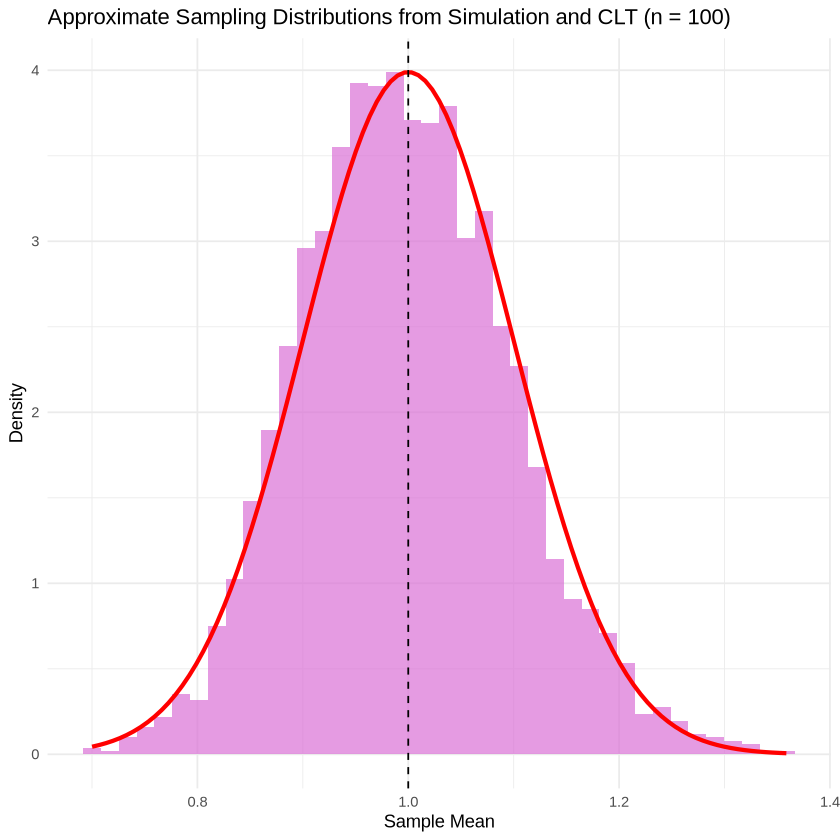

In [3]:
# answer5 <- ...(flights)
set.seed(123) # DO NOT CHANGE THE SEED

# YOUR CODE HERE
mu <- 1
sigma <- 1
sample_size <- 100
n_reps <- 3000

se_n100 <- sigma / sqrt(sample_size)

means_n100 <- replicate(n_reps, mean(rexp(sample_size, rate = 1)))
means_n100_df <- data.frame(mean = means_n100)
se_n100 <- 1 / sqrt(100)

answer5 <- ggplot(means_n100_df, aes(x = mean)) +
  geom_histogram(aes(y = after_stat(density)), bins = 40,
                 fill = "orchid", alpha = 0.7)+
  stat_function(fun = dnorm, args = list(mean = mu, sd = se_n100),
                color = "red", linewidth = 1.2) +
  geom_vline(xintercept = mu, linetype = "dashed") +
  labs(title = "Approximate Sampling Distributions from Simulation and CLT (n = 100)",
       x = "Sample Mean", y = "Density") +
  theme_minimal()


print(answer5)

In [4]:
library(digest)
stopifnot("type of answer5 is not correct"= setequal(digest(paste(toString(class(answer5)), "e0e2a")), "840e6a5e70165f64fef0b1120368cc3b"))
stopifnot("value of answer5 is not correct"= setequal(digest(paste(toString(answer5), "e0e2a")), "cdb150c6b4f6e00a558eb2784b038168"))

print('Success!')

ERROR: Error: type of answer5 is not correct


Based on the above visualization, answer the following:

1. Which pair or group of variables most frequently have missing values at the same time?

2. What might this suggest about the data collection or recording process?

*** YOUR ANSWER HERE ***

**Question 6: Visualizing missingness by categories**
{1 point}

Now visualize the amount of missing data in each variable in the flights dataset, separately for each departure airport (`origin`).

Use `gg_miss_fct()` from the `naniar` package to create a plot that shows how the number of missing values in each variable differs across airports.

Assign the resulting plot to `answer6`. 

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
#answer6 <- ...(x = ..., fct = ...)

# YOUR CODE HERE
fail()

print(answer6)

In [ ]:
library(digest)
stopifnot("type of plot is not correct (if you are using two types of geoms, try flipping the order of the geom objects!)"= setequal(digest(paste(toString(sapply(seq_len(length(answer6$layers)), function(i) {c(class(answer6$layers[[i]]$geom))[1]})), "525c2")), "d19ad369c5a5575a883e108b52845ace"))
stopifnot("variable x is not correct"= setequal(digest(paste(toString(unlist(lapply(sapply(seq_len(length(answer6$layers)), function(i) {rlang::get_expr(c(answer6$layers[[i]]$mapping, answer6$mapping)$x)}), as.character))), "525c2")), "296b1effd9b108f2e39d2466bfd23d16"))
stopifnot("variable y is not correct"= setequal(digest(paste(toString(unlist(lapply(sapply(seq_len(length(answer6$layers)), function(i) {rlang::get_expr(c(answer6$layers[[i]]$mapping, answer6$mapping)$y)}), as.character))), "525c2")), "40695a2114c2d40a75d698a3bef08e35"))
stopifnot("x-axis label is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer6$layers[[1]]$mapping, answer6$mapping)$x)!= answer6$labels$x), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("y-axis label is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer6$layers[[1]]$mapping, answer6$mapping)$y)!= answer6$labels$y), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("incorrect colour variable in answer6, specify a correct one if required"= setequal(digest(paste(toString(rlang::get_expr(c(answer6$layers[[1]]$mapping, answer6$mapping)$colour)), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("incorrect shape variable in answer6, specify a correct one if required"= setequal(digest(paste(toString(rlang::get_expr(c(answer6$layers[[1]]$mapping, answer6$mapping)$shape)), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("the colour label in answer6 is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer6$layers[[1]]$mapping, answer6$mapping)$colour) != answer6$labels$colour), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("the shape label in answer6 is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer6$layers[[1]]$mapping, answer6$mapping)$colour) != answer6$labels$shape), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("fill variable in answer6 is not correct"= setequal(digest(paste(toString(quo_name(answer6$mapping$fill)), "525c2")), "1cc2d5ae4e37af86834a18787c98e64e"))
stopifnot("fill label in answer6 is not informative"= setequal(digest(paste(toString((quo_name(answer6$mapping$fill) != answer6$labels$fill)), "525c2")), "37d850b1da1e46327f439ff098833584"))
stopifnot("position argument in answer6 is not correct"= setequal(digest(paste(toString(class(answer6$layers[[1]]$position)[1]), "525c2")), "89c56af633a2bda194cd35ee7791bc70"))

print('Success!')

Note that each row of this plot corresponds to a variable, and the colors indicate the percentage of missing values for that variable at each departure airport (columns). 

The plot shows that when a variable is missing at one airport, it is typically also missing at the other airports. However, the extent of missingness varies, with LGA with LGA showing consistently higher levels.

**Question 7: Summarizing missingness by categories**
{1 point}

In addition to visualizing missingness in datasets, `naniar` also provides tools to report summaries of the missingness within datasets. 

Use `group_by()` and `miss_var_summary()` to calculate the summary of missingness across all variables categorised by `origin`. 

Assign the resuling tibble to `answer7`. 

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
#answer7 <- ... |>
#  ...(...) |>
#  ...

# YOUR CODE HERE
fail()

print(answer7)

In [ ]:
library(digest)
stopifnot("answer7 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer7)), "67707")), "7074e65b277c022280dd83c802ee92c8"))
stopifnot("dimensions of answer7 are not correct"= setequal(digest(paste(toString(dim(answer7)), "67707")), "a1e0aed9476d5325367ecb221a80373a"))
stopifnot("column names of answer7 are not correct"= setequal(digest(paste(toString(sort(colnames(answer7))), "67707")), "47547f64a5f57ba10a8e5cfc09ac7249"))
stopifnot("types of columns in answer7 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer7, class)))), "67707")), "96f59fcd55e449a54bddb417199fe294"))
stopifnot("values in one or more numerical columns in answer7 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer7, is.numeric))) sort(round(sapply(answer7[, sapply(answer7, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "67707")), "a14fe4f81ea1ace76258e935388817ef"))
stopifnot("values in one or more character columns in answer7 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer7, is.character))) sum(sapply(answer7[sapply(answer7, is.character)], function(x) length(unique(x)))) else 0), "67707")), "4ad67af25ae1e8dc8cb60590ffcdfd00"))
stopifnot("values in one or more factor columns in answer7 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer7, is.factor))) sum(sapply(answer7[, sapply(answer7, is.factor)], function(col) length(unique(col)))) else 0), "67707")), "adf35bc451dd2e0f6433459d21926921"))

print('Success!')

## Simulation study

As we learned in a previous module of the course, we can use simulation to explore how statistical methods behave under controlled settings. In particular, we can simulate data and generate missing values.

This process allows us to control the missingness mechanism and understand how MCAR, MAR, and MNAR affect subsequent analysis and conclusions. We can also learn to recognize missing-data patterns using plots and summaries, and compare the performance of different imputation methods across scenarios.

### Linear Regression and Missing Values

You may remember from DSCI 100 that we can use [**linear regression**](https://datasciencebook.ca/regression2.html) to study the association between a continuous variable and many input variables. Least squares estimation is a commonly used method to estimate a linear regression. Whould this method be severely affected by missing values in the data?? We'll explore this through simulations!

#### Simulated Data
Let's first generate 2 input random variables (`x1` and `x2`). These are going to be the predictors. To generate these predictors, we will assume that their distribution is Normal. 

> This is an arbitrary choice, we could have used other distributions or even a complete dataset.

Next, we'll use these predictors to generate a response assuming we know its association between with the predictors. 

> In real problems we don't know the association and we estimate it with data. But in a simulation study we have full control of the data generation mechanism!

Finally, we add random noise to the response since in a random process observations do not follow exactly an assumed model. We will use a Normal distribution to generate this noise. This again is arbitrary but a common choice.

> There are many variables outside the model that we can't control and affect the observed response.

In [ ]:
#Setting seed to ensure reproducibility
set.seed(123)

n <- 100 #sample size
x1 <- rnorm(n) 
x2 <- rnorm(n) + x1
y <- 2 * x1 + 1.5 * x2 + rnorm(n)

#### Missing values

We now have a complete dataset! Let's introduce missing values, also under our control! 

In [ ]:
# Introducing missingness 
m <- sum(x1 > 0)

missing_idx <- sample(seq_len(m), size = round(0.5 * m))  # 50% missing

# introduce missingness
x2[x1 > 0][missing_idx] <- NA

simulated_data <- data.frame(x1, x2, y)

In [ ]:
head(simulated_data)

**Question 8**
{1 point}

How many missing values are there in variable `x2`? Use the following code chunk to evaluate the answer.

    A. 5
    B. 50
    C. 26
    D. 27  

*Assign your response to `answer8`.*

In [ ]:
# YOUR CODE HERE

In [ ]:
# answer8 <- "FILL_THIS_IN"

# YOUR CODE HERE
fail()

In [ ]:
library(digest)
stopifnot("type of answer8 is not character"= setequal(digest(paste(toString(class(answer8)), "57f10")), "df6a9324ce3181dd7bb338235e904194"))
stopifnot("length of answer8 is not correct"= setequal(digest(paste(toString(length(answer8)), "57f10")), "cc6ae2110366bfd79133d9633986b769"))
stopifnot("value of answer8 is not correct"= setequal(digest(paste(toString(tolower(answer8)), "57f10")), "669db8642b4f6094c5f69649e70bf7f6"))
stopifnot("letters in string value of answer8 are correct but case is not correct"= setequal(digest(paste(toString(answer8), "57f10")), "fb1578c4d8df18a21859868c34f9b9df"))

print('Success!')

What type of missingness mechanism was used to generate missing values in this simulation? Justify your answer.

*** YOUR ANSWER HERE ***

#### Visualizing missing patterns

As before, we can use `geom_miss_point()` from `naniar` to visualize patterns of missingness and explore how missing values relate to observed variables, but now using the `simulated_data` that we generated.

In [ ]:
ggplot(simulated_data,
       aes(x = x1,
           y = x2)) +
 geom_miss_point()

**Question 9: Mechanism of missingness**
{1 point}

Based on the plot above, which of the following is NOT a possible explanation for the missingess in `x2` in `simulated_data`? 

    A. MCAR (Missing Completely At Random)
    B. MAR (Missing At Random)
    C. MNAR (Missing Not At Random)
    D. None of the above

*Assign your response to `answer9`.*

In [ ]:
#assign the answer to answer1
# answer9 <- "FILL_THIS_IN"

# YOUR CODE HERE
fail()

In [ ]:
library(digest)
stopifnot("type of answer9 is not character"= setequal(digest(paste(toString(class(answer9)), "9fbd0")), "b9a33c7549e6afbe7f4e7e1f18b44b26"))
stopifnot("length of answer9 is not correct"= setequal(digest(paste(toString(length(answer9)), "9fbd0")), "92f869e336cdfee2f7e3a45819b7eb92"))
stopifnot("value of answer9 is not correct"= setequal(digest(paste(toString(tolower(answer9)), "9fbd0")), "bcde8e2e92101258d72e4a49064509b3"))
stopifnot("letters in string value of answer9 are correct but case is not correct"= setequal(digest(paste(toString(answer9), "9fbd0")), "1aeac5992ad839f840e6073d5dc30f76"))

print('Success!')

What was the justification for your choice above?

*** YOUR ANSWER HERE ***

## DATA IMPUTATION

Imputation is the process of handling missing data by replacing missing values with plausible value(s) based on the observed data.

### Deterministic Imputation

Deterministic imputation replaces each missing value with a single fixed value computed from the observed data. Common choices include the mean, median, or mode of the variable with missing values.

Although these methods are simple and easy to implement, they generate imputed values from the observed data and fail to reflect the uncertainty arising from sampling variability or from the unknown missing values.

We will begin by manually implementing deterministic imputation methods. Because we know both the true values and the mechanism that introduced the missingness in this simulated setting, we can directly examine how imputation affects the data and the resulting analysis.

**Question 10: Mean imputation**
{1 point}

Compute the mean of `x2` in `simulated_data`, ignoring missing values. Then replace all missing values in `x2` with the calculated mean. 

Assign the imputed data to the variable `answer10`. 

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
# x2_mean <- ... %>%
#  ...(x2_mean = ...(..., na.rm = ...))  %>%
#  pull(x2_mean)


# answer10 <- ... |>
#     ...(mean_imputed_x2 = case_when(...(...) ~ x2_mean,
#                      ...(...) ~ x2))

# YOUR CODE HERE
fail()


In [ ]:
library(digest)
stopifnot("answer10 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer10)), "b65c8")), "07b9e6b52b704ae57b24951200048eea"))
stopifnot("dimensions of answer10 are not correct"= setequal(digest(paste(toString(dim(answer10)), "b65c8")), "a46b94c4a4e5a78e46e799ca06cc36a7"))
stopifnot("column names of answer10 are not correct"= setequal(digest(paste(toString(sort(colnames(answer10))), "b65c8")), "857cae3fb122e45b1df24ac2ff1ecb29"))
stopifnot("types of columns in answer10 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer10, class)))), "b65c8")), "ec5e959847fd529817dac3a9dda80c5d"))
stopifnot("values in one or more numerical columns in answer10 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer10, is.numeric))) sort(round(sapply(answer10[, sapply(answer10, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "b65c8")), "1f859c3356289e5764d9dcc6ec787161"))
stopifnot("values in one or more character columns in answer10 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer10, is.character))) sum(sapply(answer10[sapply(answer10, is.character)], function(x) length(unique(x)))) else 0), "b65c8")), "b30f2c50a2b9a89d01d667d2b3b23353"))
stopifnot("values in one or more factor columns in answer10 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer10, is.factor))) sum(sapply(answer10[, sapply(answer10, is.factor)], function(col) length(unique(col)))) else 0), "b65c8")), "b30f2c50a2b9a89d01d667d2b3b23353"))

print('Success!')

Let us visualize the data after imputation and use different colors to show which values come from imputation and which come from originally observed data.

In [ ]:
ggplot(answer10,
       aes(x = x1,
           y = mean_imputed_x2,
          colour = is.na(x2))) +
 geom_point()

Describe the pattern of imputation you see in the above plot.

*** YOUR ANSWER HERE ***

### Deterministic imputation using `naniar`

Now that we understand how deterministic imputation works under the hood, we can use helper functions from `naniar` to perform the same operations more concisely. The `naniar` package has functions like `impute_mean()` and `impute_median()` that can be used to perform deterministic imputations based on mean and median, respectively.

**Question 11: Mean imputation using `naniar`**
{2 point}

Use `impute_mean()` from `naniar` to impute missing values in `x2` in `simulated_data` using the mean of the observed values. Store the imputed variable in a new column called `imputed_x2`, and call the extended dataset `answer11.1`.

Repeat the process `impute_median()` to impute missing values in `x2`, this time using the median of the observed values. 

Store the imputed variable in the same column called `imputed_x2` (it overwrite the previous imputation) and call the updated object `answer11.2`.

In [ ]:
# answer11.1 <- ... %>%
#         mutate(imputed_x2 = ...(...))

# answer11.2 <- ... %>%
#         mutate(imputed_x2 = ...(...))


# YOUR CODE HERE
fail()

head(answer11.1)

In [ ]:
library(digest)
stopifnot("answer11.1 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer11.1)), "33cf0")), "6099f8d662d98550e549e08a9af5fba7"))
stopifnot("dimensions of answer11.1 are not correct"= setequal(digest(paste(toString(dim(answer11.1)), "33cf0")), "c4c21db4bd0affd9ae89ad1855972864"))
stopifnot("column names of answer11.1 are not correct"= setequal(digest(paste(toString(sort(colnames(answer11.1))), "33cf0")), "f4d3820c4d896745786ab41129786e16"))
stopifnot("types of columns in answer11.1 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer11.1, class)))), "33cf0")), "215b53be9584091e65952ec2cc8c0c83"))
stopifnot("values in one or more numerical columns in answer11.1 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer11.1, is.numeric))) sort(round(sapply(answer11.1[, sapply(answer11.1, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "33cf0")), "bb64ba660e82c956e2c32d3e6193ea9b"))
stopifnot("values in one or more character columns in answer11.1 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer11.1, is.character))) sum(sapply(answer11.1[sapply(answer11.1, is.character)], function(x) length(unique(x)))) else 0), "33cf0")), "7becc426db88527cc6b7c3d2c8020156"))
stopifnot("values in one or more factor columns in answer11.1 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer11.1, is.factor))) sum(sapply(answer11.1[, sapply(answer11.1, is.factor)], function(col) length(unique(col)))) else 0), "33cf0")), "7becc426db88527cc6b7c3d2c8020156"))

stopifnot("answer11.2 should be a data frame"= setequal(digest(paste(toString('data.frame' %in% class(answer11.2)), "33cf1")), "8984d98eac0d63d6f30ec644b225543b"))
stopifnot("dimensions of answer11.2 are not correct"= setequal(digest(paste(toString(dim(answer11.2)), "33cf1")), "77942efd4f796420c0a52b874694bfe6"))
stopifnot("column names of answer11.2 are not correct"= setequal(digest(paste(toString(sort(colnames(answer11.2))), "33cf1")), "64a03736e66dea66cd2785afe7da2f7c"))
stopifnot("types of columns in answer11.2 are not correct"= setequal(digest(paste(toString(sort(unlist(sapply(answer11.2, class)))), "33cf1")), "ac544feb1ba2212caf2b54534f0ede62"))
stopifnot("values in one or more numerical columns in answer11.2 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer11.2, is.numeric))) sort(round(sapply(answer11.2[, sapply(answer11.2, is.numeric)], sum, na.rm = TRUE), 2)) else 0), "33cf1")), "e9feea668e7c575082cf10237ec1cbb0"))
stopifnot("values in one or more character columns in answer11.2 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer11.2, is.character))) sum(sapply(answer11.2[sapply(answer11.2, is.character)], function(x) length(unique(x)))) else 0), "33cf1")), "897b6a4cb574c868677c796f58a3996c"))
stopifnot("values in one or more factor columns in answer11.2 are not correct"= setequal(digest(paste(toString(if (any(sapply(answer11.2, is.factor))) sum(sapply(answer11.2[, sapply(answer11.2, is.factor)], function(col) length(unique(col)))) else 0), "33cf1")), "897b6a4cb574c868677c796f58a3996c"))

print('Success!')

### Multiple imputation using `mice`

Multiple imputation methods have been proposed to overcome the limitations of deterministic imputation, replacing each missing value with multiple plausible values to incorporate uncertainty in the imputation process. As a result, instead of one completed dataset after imputation, we generate several and combine the results at the end.

The `mice` package (Multiple Imputation by Chained Equations) is one of the commonly used packages to perform multiple imputations. Rather than filling in missing values once, `mice` acknowledges that there are many reasonable values a missing observation could take. 

In this section, you will use mice to generate multiple imputed datasets and examine how this affects downstream regression results compared to deterministic and complete-case analyses.

In [ ]:
library(mice)

Now let us use `mice` to perform data imputation of `x2` variable in the `simulated_data`. `mice` will impute the `x2` variable based off of all the other variables in the dataset, in our case,`x1` and `y`.

> **imputation is not prediction:** it sounds suspecious to use `y` to impute a predictor. The idea of imputation is to recover missing data using the existing known relation between variables. You can read more about his [**here**](https://stefvanbuuren.name/fimd/sec-true.html).

In [ ]:
# Running mice on the simulated_data
imp <- mice(simulated_data, m = 5, maxit = 10, seed = 123, printFlag = FALSE)
imp

The argument `m` controls how many complete (imputed) datasets are created. Thus `m = 5` means 5 different versions of the complete dataset are generated each of which contains different imputed values for the missing entries. 

Larger `m` better captures uncertainty but increases computation time. `mice` performs multiple iterations of the chained equations algorithm to perform imputation. The number of iterations can be controlled by `maxit` argument. More iterations allow the algorithm to stabilize.

After imputation, mice stores all completed datasets internally.  We can extract individual complete datasets using `complete()` as shown below. `action=1` extracts the first completed dataset. Similarly you can extract any of the `m` datasets individually.

In [ ]:
cc1 <- complete(imp, action = 1)

head(cc1)

Now let us compare the imputed values from both the deterministic approach and using `mice`. To do that, we will first create a dataset that has imputed values from both approaches together.

In [ ]:
imp_compare <- cc1 |>
 rename(mice_imputed_x2=x2) |>
 left_join(answer10) |>
 select(x1, x2, y, everything()) |>
 pivot_longer(cols = -c(x1, x2, y), names_to = "Imputation", values_to = "Imputed_x2")

head(imp_compare)

**Question 12: Imputation using `mice`**
{1 point}

Visualize the imputed `x2` values from both the imputation methods and color them based on the missingness of the non-imputed `x2`. 

Assign the imputed data to the variable `answer12`.

*Replace the ... in the code chunk below with appropriate code. Uncomment lines corresponding to code and run it.*

In [ ]:
# answer12 <- ggplot(imp_compare,
#        aes(x = x1,
#            y = ...,
#           colour = is.na(...))) +
#  geom_point() +
#  facet_wrap(~...)

# YOUR CODE HERE
fail()

answer12

In [ ]:
library(digest)
stopifnot("type of plot is not correct (if you are using two types of geoms, try flipping the order of the geom objects!)"= setequal(digest(paste(toString(sapply(seq_len(length(answer12$layers)), function(i) {c(class(answer12$layers[[i]]$geom))[1]})), "1f854")), "87022cd5bbacaf21ced29266b231bd95"))
stopifnot("variable x is not correct"= setequal(digest(paste(toString(unlist(lapply(sapply(seq_len(length(answer12$layers)), function(i) {rlang::get_expr(c(answer12$layers[[i]]$mapping, answer12$mapping)$x)}), as.character))), "1f854")), "e909a5979d617a7452d1e1b1fda14f80"))
stopifnot("variable y is not correct"= setequal(digest(paste(toString(unlist(lapply(sapply(seq_len(length(answer12$layers)), function(i) {rlang::get_expr(c(answer12$layers[[i]]$mapping, answer12$mapping)$y)}), as.character))), "1f854")), "7d0a6073f32596cc64c375c017b48e23"))
stopifnot("x-axis label is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer12$layers[[1]]$mapping, answer12$mapping)$x)!= answer12$labels$x), "1f854")), "e3524c1c8edb8c72d1e87f70fbea1b65"))
stopifnot("y-axis label is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer12$layers[[1]]$mapping, answer12$mapping)$y)!= answer12$labels$y), "1f854")), "e3524c1c8edb8c72d1e87f70fbea1b65"))
stopifnot("incorrect colour variable in answer12, specify a correct one if required"= setequal(digest(paste(toString(rlang::get_expr(c(answer12$layers[[1]]$mapping, answer12$mapping)$colour)), "1f854")), "d1ba4cae32d450c0fbd3d79b75ecb091"))
stopifnot("incorrect shape variable in answer12, specify a correct one if required"= setequal(digest(paste(toString(rlang::get_expr(c(answer12$layers[[1]]$mapping, answer12$mapping)$shape)), "1f854")), "e3524c1c8edb8c72d1e87f70fbea1b65"))
stopifnot("the colour label in answer12 is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer12$layers[[1]]$mapping, answer12$mapping)$colour) != answer12$labels$colour), "1f854")), "e3524c1c8edb8c72d1e87f70fbea1b65"))
stopifnot("the shape label in answer12 is not descriptive, nicely formatted, or human readable"= setequal(digest(paste(toString(rlang::get_expr(c(answer12$layers[[1]]$mapping, answer12$mapping)$colour) != answer12$labels$shape), "1f854")), "e3524c1c8edb8c72d1e87f70fbea1b65"))
stopifnot("fill variable in answer12 is not correct"= setequal(digest(paste(toString(quo_name(answer12$mapping$fill)), "1f854")), "7236e13a0a0320bfd3b484aeb2369e9b"))
stopifnot("fill label in answer12 is not informative"= setequal(digest(paste(toString((quo_name(answer12$mapping$fill) != answer12$labels$fill)), "1f854")), "e3524c1c8edb8c72d1e87f70fbea1b65"))
stopifnot("position argument in answer12 is not correct"= setequal(digest(paste(toString(class(answer12$layers[[1]]$position)[1]), "1f854")), "373b52e24148a1e040b37abbd2c674c8"))

print('Success!')

Describe the trend you see betweent the two imputation methods. Is one better than the other?

*** YOUR ANSWER HERE ***

### Impact of imputation on downstream analysis

In this section, we examine how different strategies for handling missing data affect statistical modelling results. The goal is to understand not only how estimates change, but why they change. We will compare four approaches:

    1. Complete-case analysis
    2. Deterministic mean/median imputation
    3. Single imputed dataset from MICE (action = 1)
    4. Proper multiple imputation with pooling

We will use the use the simulated dataset again since we know model parameters used to generate the data.

#### Complete-case analysis

Let's use the entire `simulated_data` this time. The `lm()` function **automatically** discards any rows with missing values in the predictor variables, `x1` and `x2` in our case. In other words, the model is only built on complete-case data points.

In [ ]:
model_cc <- lm(y ~ x1 + x2, data = simulated_data)
summary(model_cc)

Note that the summary tells you that "26 observations deleted due to missingness". This reduces our sample size and increases our uncertainty in coefficient estimates.

> Other summary functions, e.g., `tidy()`, remain very silent about this fact.

In [ ]:
tidy(model_cc)

Since we generated the data from a linear model, we know what the true regression coefficients (number that multiplies the predictors in the model) are. In our case,

- intercept = 0
- coefficient of `x1` = 2
- coefficient of `x2` = 1.5

The estimates we got using the generated complete data and least squares estimation are shown in the column `estimate` of the table above.

Are these good estimates?? We'll come back to this question.

#### Deterministic imputation 

We will now use the **mean** of `x2` to impute all its missing values.

**Question 13: mean imputation and LS**
{1 point}

Implement mean imputation of `x2` on `simulated_data_random`. Use the `lm()` function to estimate the linear model based on the imputed data and store the model summary in `answer13`.

*Follow the example of the complete-case to write your own code and run it.*

In [ ]:
# Your code goes here


# YOUR CODE HERE
fail()
answer13

In [ ]:
library(digest)
stopifnot("type of answer13 is not correct"= setequal(digest(paste(toString(class(answer13)), "e8e6a")), "d07d6be3b9fd3e21fa97ecc5ec2c5238"))
stopifnot("value of answer13 is not correct"= setequal(digest(paste(toString(answer13), "e8e6a")), "d7f2953881f649c2c33c7b44cc316ecb"))

print('Success!')

The estimates of the regression coefficients using the mean-imputed data seem to be worse than those obtained using complete data. But perhaps that is an artifact from this dataset ...

#### Single imputed dataset from `mice` (action=1)

**Question 14: `mice` imputation with single dataset extracted and LS**
{1 point}

Use `mice` to generate multiple imputations of `x2` but consider only one of the imputed datasets.

Set `m=5` to generate 5 imputed datasets, `maxit = 10` and `seed=123`. 

Extract the first imputed dataset and use it to estimate the linear model using the `lm()` function as before. Store the model summary in `answer14`. 

*Replace the ... in the code chunk below with appropriate code. Check previous cells or help functions if needed. Uncomment lines corresponding to code and run it.*

In [ ]:
# mice_imp <- ... %>%
#     mice(m = ..., maxit = ..., seed = ..., printFlag =  FALSE)

# comp_case <- ...(mice_imp, action = ...)

# model_mice1 <- ...(y ~ ..., data = ...)
# answer14 <- ...(model_mice1)

# YOUR CODE HERE
fail()
answer14

In [ ]:
library(digest)
stopifnot("type of answer14 is not correct"= setequal(digest(paste(toString(class(answer14)), "98510")), "0c782ee9ea51c883b951495696834175"))
stopifnot("value of answer14 is not correct"= setequal(digest(paste(toString(answer14), "98510")), "db86dc769aa0ab13fc62bb8878dd9d6b"))

print('Success!')

How does these coefficient estimates compare to the previous ones? But we had 5 imputed dataset, so why using only one? In doing so, we are ignoring the uncertainty that `mice` is designed to capture through multiple imputation.

#### Multiple imputation using `mice`

We now fit the same regression model to each imputed dataset generated by `mice` and pool the results to obtain valid coefficient estimates and standard errors.

In [ ]:
fit_imp <- with(mice_imp, lm(y ~ x1+x2))
pooled <- pool(fit_imp)
summary(pooled)

**Question 15: `mice` with multiple imputations and LS:**

**1.** What does `pool()` in multiple imputation using mice? (1 point)

    A. `pool()` combines the imputed datasets into a single completed dataset
    B. `pool()` accounts for both within-imputation and between-imputation variability
    C. `pool()` averages coefficient estimates but ignores standard errors
    D. `pool()` corrects bias introduced by complete-case analysis

*Assign your answer to `answer15.1`*

In [ ]:
# answer15.1 <- "FILL_THIS_IN"

# YOUR CODE HERE
fail()

In [ ]:
library(digest)
stopifnot("type of answer15.1 is not character"= setequal(digest(paste(toString(class(answer15.1)), "284b0")), "9d99311df12f23034654aa617100bd21"))
stopifnot("length of answer15.1 is not correct"= setequal(digest(paste(toString(length(answer15.1)), "284b0")), "a9088dff0b7bdaa146a780aefc3b6ddc"))
stopifnot("value of answer15.1 is not correct"= setequal(digest(paste(toString(tolower(answer15.1)), "284b0")), "b87ea703a0359dcde9448fe4d527f682"))
stopifnot("letters in string value of answer15.1 are correct but case is not correct"= setequal(digest(paste(toString(answer15.1), "284b0")), "78c610bebc0cebd7acf61afff6aed455"))

print('Success!')

**2.** Which of the following statements is correct regarding the use of a single imputed dataset from mice (action = 1) for regression analysis? (1 point)

    A. It provides valid inference because the imputed values are generated from a model
    B. It is equivalent to pooled multiple imputation when sample size is large
    C. It ignores between-imputation variability and therefore underestimates uncertainty
    D. It is only invalid when missingness is MNAR

In [ ]:
#assign the answer to answer15.2
# answer15.2 <- "FILL_THIS_IN"

# YOUR CODE HERE
fail()

In [ ]:
library(digest)
stopifnot("type of answer15.2 is not character"= setequal(digest(paste(toString(class(answer15.2)), "d000d")), "cafa60fd4e6e9af2551ab8add83d0013"))
stopifnot("length of answer15.2 is not correct"= setequal(digest(paste(toString(length(answer15.2)), "d000d")), "f75bd4776a445d5d20b910aa62001df5"))
stopifnot("value of answer15.2 is not correct"= setequal(digest(paste(toString(tolower(answer15.2)), "d000d")), "3688b439de19a72710b630c92648991b"))
stopifnot("letters in string value of answer15.2 are correct but case is not correct"= setequal(digest(paste(toString(answer15.2), "d000d")), "4bbaded9a0b8c621ebfa897e1b7f9f6f"))

print('Success!')

### Replication

In the previous question we only had one dataset to work with. But we learn that to study properties of estimators we need to replicate the random process and analysis. 

In this part, we will compare the behaviour of the estimators over **many different datasets generated with the same missingness mechanism**. 

Since we need to create multiple datasets, introduce missingness, under the same conditions, and perform several analysis multiple times, we created some helper functions.

> We won't ask you to write functions in this course but it is helpful to start learning about them.

In [ ]:
# Helper functions

# Generate data
generate_data <- function(b0, b1, b2, sigma2 = 1, n ){
x1 <- rnorm(n) 
x2 <- rnorm(n) + x1
y  <- b0 + b1 * x1 + b2 * x2 + rnorm(n)

simulated_data <- data.frame(x1, x2, y)
simulated_data
    }

# Generate missingness
generate_missing <- function(df, p) {
  df <- df  # copy
  idx_pos <- which(df$x1 > 0)
  cond_n <- length(idx_pos)

  missing_idx <- sample(idx_pos, size = round(p * cond_n))
  df$x2[missing_idx] <- NA
  df
}

# Estimate linear regression
fit_lm <- function(df) {
  lm(y ~ x1 + x2, data = df) %>%
    tidy() %>%
    select(term, estimate)
}

# Mean imputation, then LS estimation
est_mean_imp <- function(df) {
  df %>%
    mutate(x2 = impute_mean(x2)) %>%
    fit_lm()
}

# mice imputation, then LS estimation on ONE and POOLED 
est_mice <- function(df, m = 5, maxit = 10, seed = 123) {
  imp <- mice(df, m = m, maxit = maxit, seed = seed, printFlag = FALSE)

    # one complete dataset
 one <- complete(imp, action = 1) %>%
    fit_lm() %>%
        select(term, estimate) %>%
        mutate(method = "MICE (Single)")

  # pooled across m imputations
  pooled <- pool(with(imp, lm(y ~ x1 + x2))) %>%
    summary() %>%
    select(term, estimate) %>%
    mutate(method = "MICE (Pooled)")

  bind_rows(one, pooled)
}

You can try using these functions, to understand their input and output values.

In [ ]:
#generate 100 data points from the linear model in previous questions
set.seed(123)

data100 <- generate_data(0, 1, 1.5, sigma2 = 1, 100)

head(data100)
dim(data100)

In [ ]:
#generate 60% missing values to the `data100` dataset

data100_miss <- generate_missing(data100,0.6)
head(data100_miss)

df <- data100_miss

Now that we have functions to generate data and add missingness, we can replicate the process multiple times!! Let's replicated 1000 times.

In [ ]:
set.seed(200)

simulated_data <- generate_data(
      b0 = 0, b1 = 2, b2 = 1.5,
      sigma2 = 1, n = 100
    )

datasets <- replicate(
  1000,
  {#simulate each dataset
    simulated_data <- generate_data(
      b0 = 0, b1 = 2, b2 = 1.5,
      sigma2 = 1, n = 100
    )
    #add missing values  
    generate_missing(simulated_data, p = 0.3)
  },
  simplify = FALSE
)

# Check the object
class(datasets)
length(datasets)
dim(datasets[[1]])

The following block computes the coefficients for each of the four imputation methods, and on each of the 1000 generated datasets. 

> we use the function `sapply`, which applys the function in the second argument to each element of the list in the first argument.

In [ ]:
complete_coeff <- datasets %>%
  map_dfr(fit_lm, .id = "rep")

In [ ]:
head(complete_coeff)

In [ ]:
mean_imp_coeff <- datasets %>%
  map_dfr(est_mean_imp, .id = "rep")

head(mean_imp_coeff)

In [ ]:
mice_coeff <- datasets %>%
  map_dfr(est_mice, .id = "rep")

head(mice_coeff)

In [ ]:
all_x2 <- bind_rows(
  complete_coeff     %>% mutate(method = "Complete case"),
  mean_imp_coeff     %>% mutate(method = "Mean imputation"),
  mice_coeff        
) %>%
  filter(term == "x2")

tail(all_x2)

In [ ]:
coef_x2_df <- bind_rows(
  complete_coeff     %>% mutate(method = "Complete case"),
  mean_imp_coeff     %>% mutate(method = "Mean imputation"),
  mice_coeff        
) %>%
  filter(term == "x2")

ggplot(coef_x2_df, aes(x = estimate, fill = method)) +
  geom_histogram(
    bins = 20,
    alpha = 0.5,
    position = "identity"
  ) +
  geom_vline(xintercept = 1.5, linetype = "dashed") +
  facet_wrap(~ method, scales = "free_y") +
  labs(
    title = "Sampling Distribution of `x2` Coefficient Estimator",
    x = "Estimated coefficient",
    y = "Count"
  ) +
  theme(legend.position = "none")

We know, by design of the simulation, that the true value of the coefficient of `x2` is 1.5 (shown by the vertical line). Which imputation method shows the largest bias?

** YOUR ANSWER HERE **

### Future work

While some estimators do not seem to be affected by the imputation, the standard errors may be affected differently across methods.

The functions that we wrote extract the estimates of the coefficients but you can also extract the standard errors called "Std. Error" by the `summary()` function of `lm()`.

**Give it a try! You can re-use most of the simulation set up!!**